# Chapter 48: Pseudo-Labeling for CV

**Does a stricter confidence threshold make pseudo-labeling pay, and does it remove the leak from a teacher that saw the validation labels?**

The chapter says a confidence threshold controls selection but does not prove correctness, and cannot repair teacher leakage. Sixteen constructed worlds put numbers on both statements: which threshold helps the student, and how large the cross-validation error from a leaky teacher is at each.

*Constructed data and a teacher that memorises; the sizes of these effects are properties of this generator, not a competition result.*

## The experiment

Constructed binary task in six dimensions with three noisy clusters per class: 100 labeled rows, 1,000 unlabeled pool rows with known labels used only for scoring, and 2,000 fresh rows. The teacher is an extremely randomized trees classifier (it memorises its training rows); the student is a second trees model trained on the labeled rows plus the pool rows whose top teacher probability reaches the control's threshold, using the teacher's labels. The student is compared with the same model trained on labeled rows only. Three-fold cross-validation of the whole pipeline is run twice: with one teacher trained on all 100 labeled rows (so it has seen every validation label) and with a teacher rebuilt from each fold's training rows. Each estimate is compared with the score on fresh rows of the same student models, averaged over 16 worlds.

In [1]:
import numpy as np
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold

from kaggle_companion.activities._common import clean

SEED = 48
DRAWS = 16                  # independent worlds; every estimate is a mean over draws
N_LABELED, N_POOL, N_FRESH = 100, 1000, 2000
DIM, NOISE = 6, 1.6        # features per row and within-cluster noise


def make_world(rng):
    """Three clusters per class in six dimensions: the same world supplies labeled rows, the unlabeled pool and fresh rows."""
    return rng.normal(size=(3, DIM)) * 2.0, rng.normal(size=(3, DIM)) * 2.0


def sample(world, n, rng):
    y = (rng.random(n) < 0.5).astype(int)
    cluster = rng.integers(0, 3, n)
    X = np.where(y[:, None] == 1, world[1][cluster], world[0][cluster]) + NOISE * rng.normal(size=(n, DIM))
    return X, y


def teacher(seed):
    """High-capacity teacher: it memorises the labeled rows it is trained on (which is what makes leakage matter)."""
    return ExtraTreesClassifier(n_estimators=30, random_state=seed, n_jobs=1)


def student(seed):
    return ExtraTreesClassifier(n_estimators=30, min_samples_leaf=3, random_state=seed, n_jobs=1)


def pseudo_set(teacher_X, teacher_y, pool, threshold, seed):
    """Fit a teacher, keep the pool rows whose top class probability reaches the threshold, and return rows and pseudo-labels."""
    prob = teacher(seed).fit(teacher_X, teacher_y).predict_proba(pool)
    keep = prob.max(1) >= threshold
    return pool[keep], prob.argmax(1)[keep], keep, prob.argmax(1)


def run(threshold):
    rng = np.random.default_rng(SEED)
    keys = ("coverage", "pseudo_accuracy", "supervised", "teacher_alone", "student", "leaky_estimate", "leaky_true", "nested_estimate", "nested_true",
            "supervised_estimate")
    rows = {k: [] for k in keys}
    for draw in range(DRAWS):
        world = make_world(rng)
        X, y = sample(world, N_LABELED, rng)
        pool, pool_y = sample(world, N_POOL, rng)
        X_fresh, y_fresh = sample(world, N_FRESH, rng)
        # Final pipeline: teacher on all labeled rows, student on labeled rows plus confident pseudo-labels.
        px, py, keep, guess = pseudo_set(X, y, pool, threshold, draw)
        rows["coverage"].append(keep.mean())
        rows["pseudo_accuracy"].append((py == pool_y[keep]).mean() if keep.any() else np.nan)
        rows["supervised"].append(student(draw).fit(X, y).score(X_fresh, y_fresh))
        rows["teacher_alone"].append(teacher(draw).fit(X, y).score(X_fresh, y_fresh))   # the other supervised candidate
        rows["student"].append(student(draw).fit(np.vstack([X, px]), np.r_[y, py]).score(X_fresh, y_fresh))
        # Three-fold cross-validation of the whole pipeline, with the teacher either global (leaky) or rebuilt per fold.
        cells = {k: [] for k in ("leaky_estimate", "leaky_true", "nested_estimate", "nested_true", "supervised_estimate")}
        for fit, hold in StratifiedKFold(3, shuffle=True, random_state=draw).split(X, y):
            for tag, (tx, ty) in (("leaky", (X, y)), ("nested", (X[fit], y[fit]))):    # global teacher sees the hold-out labels
                px_f, py_f, _, _ = pseudo_set(tx, ty, pool, threshold, draw)
                model = student(draw).fit(np.vstack([X[fit], px_f]), np.r_[y[fit], py_f])
                cells[tag + "_estimate"].append(model.score(X[hold], y[hold]))
                cells[tag + "_true"].append(model.score(X_fresh, y_fresh))
            cells["supervised_estimate"].append(student(draw).fit(X[fit], y[fit]).score(X[hold], y[hold]))
        for k, v in cells.items():
            rows[k].append(np.mean(v))
    mean = {k: float(np.nanmean(v)) for k, v in rows.items()}
    gain = np.array(rows["student"]) - np.array(rows["supervised"])
    gain_vs_teacher = np.array(rows["student"]) - np.array(rows["teacher_alone"])
    leak = np.array(rows["leaky_estimate"]) - np.array(rows["leaky_true"])
    honest = np.array(rows["nested_estimate"]) - np.array(rows["nested_true"])
    return clean({
        "threshold": threshold, **mean,
        "gain": gain.mean(), "gain_se": gain.std(ddof=1) / np.sqrt(DRAWS), "gain_win_rate": float((gain > 0).mean()),
        "gain_vs_teacher": gain_vs_teacher.mean(), "gain_vs_teacher_se": gain_vs_teacher.std(ddof=1) / np.sqrt(DRAWS),
        "leaky_error": leak.mean(), "leaky_error_se": leak.std(ddof=1) / np.sqrt(DRAWS),
        "nested_error": honest.mean(), "nested_error_se": honest.std(ddof=1) / np.sqrt(DRAWS),
        "per_draw": {"supervised": rows["supervised"], "student": rows["student"]},
        "labeled": N_LABELED, "pool": N_POOL, "fresh": N_FRESH, "draws": DRAWS,
    })


## Measure it across the control

The control is **confidence threshold for keeping a pseudo-label**. Each value below runs the whole experiment from the generator up.

In [2]:
import pandas as pd
from kaggle_companion.activities.ch48 import explain

VALUES = [0.6, 0.8, 0.9, 0.99]
results = {value: run(value) for value in VALUES}
table = pd.DataFrame({str(v): explain(results[v], v)['metrics'] for v in VALUES})
print(table.to_string())

                                          0.6             0.8             0.9            0.99
Pseudo-labels kept                      88.8%           57.3%           35.3%            8.3%
Pseudo-label accuracy                   91.1%           96.2%           98.1%           99.7%
Student gain (standard error)  +0.020 (0.003)  +0.012 (0.003)  +0.006 (0.003)  -0.003 (0.003)
Leaky CV error                         +0.040          +0.043          +0.033          +0.029
Nested CV error                        +0.007          +0.015          +0.003          +0.015
Supervised accuracy, fresh              0.866           0.866           0.866           0.866


## Look at it

The figure shows the default setting, confidence threshold for keeping a pseudo-label = 0.9.

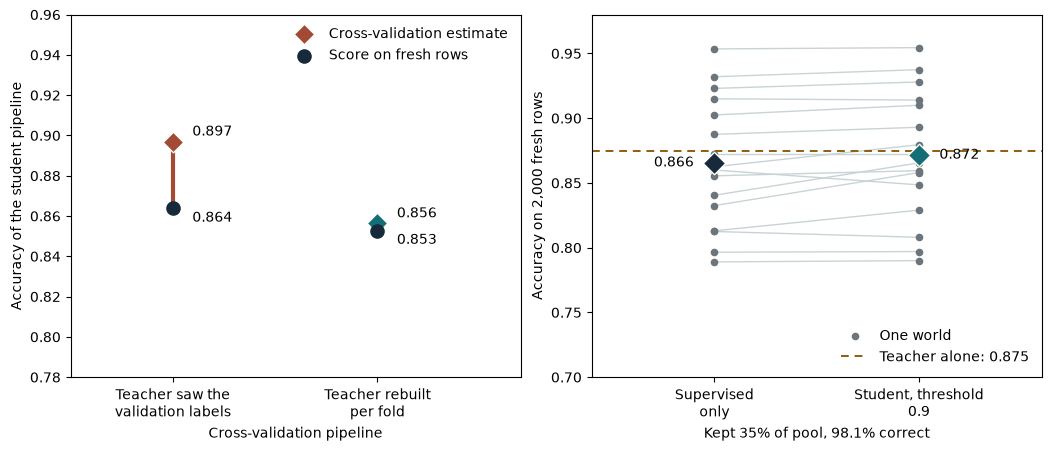

In [3]:
import matplotlib.pyplot as plt
from kaggle_companion.activities.ch48 import draw, NCOLS, HEIGHT

DEFAULT = 0.9
fig, axes = plt.subplots(1, NCOLS, figsize=(6.6 if NCOLS == 1 else 10.4, HEIGHT), layout='constrained')
draw(axes, results[DEFAULT], DEFAULT)
plt.show()

## What the result says

At threshold 0.9 the teacher's labels are kept for 35.3% of the pool and are 98.1% correct. The student scores 0.872 on fresh rows against 0.866 for the supervised model: 0.872 - 0.866 = 0.006 (standard error 0.003). The gain is small, between two and three standard errors, and may not survive another seed. Cross-validation with a teacher that saw all labeled rows reports 0.897 against a fresh score of 0.864, an error of +0.033; rebuilding the teacher inside each fold gives an error of +0.003. The teacher used alone scores 0.875 on fresh rows, so the student is -0.003 against the better of the two supervised models.

- Student gain on fresh rows: 0.872 - 0.866 = +0.006.
- Leaky estimate error: 0.897 - 0.864 = +0.033 (standard error 0.009).
- Nested estimate error: 0.856 - 0.853 = +0.003 (standard error 0.008).
- Pseudo-labels kept: 35.3% of 1000 pool rows, 98.1% correct.

## Apply this to your competition

- Rebuild the teacher inside every outer fold from that fold's training labels, and generate pseudo-labels only for permitted recipients.
- Compare the student with the best supervised-only model, the teacher included, on genuine held-out labels; do not judge a threshold by the accuracy of its pseudo-labels.
- Report coverage with accuracy: a threshold that keeps few rows can be accurate and useless.
- Audit the kept rows by class, source or subject where genuine labels exist, to catch concentrated pseudo-labels.

Book location: Chapter 48, What Can Go Wrong.

[Technical corrections](https://github.com/KarpelesPublishing/winning-kaggle-companion/blob/main/docs/errata.md)